# BUTD Image Captioning — Google Colab

This notebook runs on **Google Colab with a GPU runtime** and covers:
1. Mount Google Drive and set up the project
2. Install dependencies
3. Extract Faster R-CNN region features
4. Train the BUTD decoder
5. Evaluate BLEU / METEOR on the validation split

---
### Before running
1. **Runtime → Change runtime type → T4 GPU**
2. Upload your project folder to Google Drive so the path looks like:
   ```
   MyDrive/
   └── deeplearning-project/
       ├── data/
       │   ├── Images/        ← Flickr30k .jpg files
       │   └── captions.txt
       ├── metadata/
       ├── src/
       ├── scripts/
       └── notebooks/
   ```

## 1. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import sys

# ---- Edit this if your folder is in a subfolder of MyDrive ----
PROJECT_ROOT = "/content/drive/MyDrive/deeplearning-project"
# ---------------------------------------------------------------

os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Working directory:", os.getcwd())
print("Contents:", os.listdir("."))

Working directory: /content/drive/MyDrive/deeplearning-project
Contents: ['README.md', '.gitignore', 'requirements.txt', 'tests', 'scripts', 'src', 'notebooks', 'metadata', 'data', 'configs', '.github', '.git', 'Untitled0.ipynb', 'checkpoints']


## 2. Install Dependencies

In [ ]:
# Colab ships with torch and torchvision pre-installed.
# We only need to add nltk (for BLEU/METEOR evaluation).
!pip install -q nltk

import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

import torch
import torchvision
print(f"torch       : {torch.__version__}")
print(f"torchvision : {torchvision.__version__}")
print(f"GPU         : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NOT AVAILABLE — change runtime to GPU'}")

torch       : 2.10.0+cu128
torchvision : 0.25.0+cu128
GPU         : Tesla T4


## 3. Configuration

In [ ]:
from pathlib import Path

# --- Paths ---
CAPTIONS_PATH  = Path("data/captions.txt")
IMAGES_DIR     = Path("data/Images")
FEATURES_DIR   = Path("data/butd_features")
VOCAB_PATH     = Path("metadata/vocab/flickr30k_vocab.json")
SPLITS_DIR     = Path("metadata/splits")
CHECKPOINT_DIR = Path("checkpoints/butd")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# --- Model hyperparameters ---
NUM_REGIONS   = 36
FEATURE_DIM   = 1024
EMBED_DIM     = 512
HIDDEN_DIM    = 512
ATTENTION_DIM = 512
DROPOUT       = 0.5

# --- Training hyperparameters ---
BATCH_SIZE  = 32
LR          = 4e-4
GRAD_CLIP   = 5.0
NUM_EPOCHS  = 20
LR_STEP     = 5
LR_GAMMA    = 0.5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 4. Feature Extraction

Runs Faster R-CNN over all ~31k Flickr30k images and saves a `(36, 1024)` tensor per image to `data/butd_features/`.

**Expected time: ~ 60 minutes on a T4 GPU.**

The script is idempotent — already-extracted images are skipped automatically.

In [ ]:
from src.data.splits import load_split_file

train_ids = load_split_file(SPLITS_DIR / "train.txt")
val_ids   = load_split_file(SPLITS_DIR / "val.txt")
test_ids  = load_split_file(SPLITS_DIR / "test.txt")
all_ids   = train_ids + val_ids + test_ids

FEATURES_DIR.mkdir(parents=True, exist_ok=True)
missing = [iid for iid in all_ids if not (FEATURES_DIR / f"{iid}.pt").exists()]
print(f"Images total   : {len(all_ids)}")
print(f"Features ready : {len(all_ids) - len(missing)}")
print(f"Missing        : {len(missing)}")

Images total   : 31783
Features ready : 31783
Missing        : 0


In [ ]:
if missing:
    print("Starting feature extraction …")
    !python scripts/extract_butd_features.py \
        --images-dir  data/Images \
        --output-dir  data/butd_features \
        --splits-dir  metadata/splits \
        --num-regions 36 \
        --batch-size  4 \
        --device      cuda

else:
    print("All features already extracted — skipping.")

All features already extracted — skipping.


In [ ]:
# Verify a feature file looks correct
sample_id = all_ids[0]
sample_feat = torch.load(FEATURES_DIR / f"{sample_id}.pt", weights_only=True)
print(f"Sample feature shape : {sample_feat.shape}")          # should be (36, 1024)
print(f"dtype                : {sample_feat.dtype}")          # float32
print(f"Total .pt files now  : {len(list(FEATURES_DIR.glob('*.pt')))}")  # ~31k

Sample feature shape : torch.Size([36, 1024])
dtype                : torch.float32
Total .pt files now  : 31783


## 5. Dataset and DataLoaders

In [ ]:
import shutil, os

LOCAL_FEATURES = "/content/butd_features"

if not os.path.exists(LOCAL_FEATURES):
    print("Copying BUTD features to local SSD (one-time, ~1hr)…")
    shutil.copytree(str(FEATURES_DIR), LOCAL_FEATURES)
    print("Done.")
else:
    print("Local features already present.")

# Point the loaders at the local copy
LOCAL_FEATURES_DIR = Path(LOCAL_FEATURES)


Copying BUTD features to local SSD (one-time, ~2–5 min)…
Done.


In [ ]:
from src.data.vocab import Vocabulary
from src.data.splits import load_caption_map
from src.data.butd_dataset import create_butd_dataloader

vocab = Vocabulary.load(VOCAB_PATH)
vocab_size = len(vocab.word2idx)
print(f"Vocabulary size : {vocab_size}")

caption_map = load_caption_map(CAPTIONS_PATH)

train_loader = create_butd_dataloader(
    caption_map=caption_map,
    features_dir=LOCAL_FEATURES,
    split_image_ids=train_ids,
    vocab=vocab,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
)

val_loader = create_butd_dataloader(
    caption_map=caption_map,
    features_dir=LOCAL_FEATURES,
    split_image_ids=val_ids,
    vocab=vocab,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
)

print(f"Train batches : {len(train_loader)}  ({len(train_loader.dataset)} samples)")
print(f"Val batches   : {len(val_loader)}  ({len(val_loader.dataset)} samples)")

Vocabulary size : 7013
Train batches : 3973  (127130 samples)
Val batches   : 497  (15890 samples)


In [ ]:
# Quick shape sanity check
sample_batch = next(iter(train_loader))
print("features     :", sample_batch["features"].shape)     # (B, 36, 1024)
print("caption_ids  :", sample_batch["caption_ids"].shape)  # (B, T)
print("target_ids   :", sample_batch["target_ids"].shape)   # (B, T)
print("Sample caption:", sample_batch["caption_texts"][0])

features     : torch.Size([32, 36, 1024])
caption_ids  : torch.Size([32, 27])
target_ids   : torch.Size([32, 27])
Sample caption: A group of party-goers are on a balcony drinking and eating with plastic lei 's around their necks .


## 6. Model

In [ ]:
from src.models.butd_model import BUTDCaptionModel

model = BUTDCaptionModel(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    feature_dim=FEATURE_DIM,
    attention_dim=ATTENTION_DIM,
    dropout=DROPOUT,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

Trainable parameters: 18,470,245


In [ ]:
# Forward-pass smoke test
model.eval()
with torch.no_grad():
    test_feats = sample_batch["features"][:2].to(device)
    test_caps  = sample_batch["caption_ids"][:2].to(device)
    logits = model(test_feats, test_caps)
    print(f"Logits shape : {logits.shape}  — expected (2, T, {vocab_size})")
    gen = model.generate(test_feats, vocab.word2idx["<start>"], vocab.word2idx["<end>"])
    print(f"Generated    : {' '.join(vocab.decode(gen[0].tolist()))}")
model.train();

Logits shape : torch.Size([2, 27, 7013])  — expected (2, T, 7013)
Generated    : muzzled amused amused combat combat combat amused mexican mexican mexican mexican mexican mexican mexican mexican mexican mexican photographers combat combat combat combat amused mexican mexican mexican mexican mexican mexican mexican mexican mexican photographers combat combat combat combat amused mexican mexican


## 7. Training

Expect training to last up to 3hrs on GPU

In [ ]:
import torch.nn as nn
import torch.optim as optim
from src.training.train_butd import train_one_epoch, evaluate_loss

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP, gamma=LR_GAMMA)

train_losses = []
val_losses   = []
best_val_loss = float("inf")

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device, GRAD_CLIP)
    val_loss   = evaluate_loss(model, val_loader, criterion, device)
    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    flag = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": val_loss,
                "hparams": {
                    "vocab_size": vocab_size,
                    "embed_dim": EMBED_DIM,
                    "hidden_dim": HIDDEN_DIM,
                    "feature_dim": FEATURE_DIM,
                    "attention_dim": ATTENTION_DIM,
                },
            },
            CHECKPOINT_DIR / "best.pt",
        )
        flag = "  ← best"

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS}  "
        f"train={train_loss:.4f}  "
        f"val={val_loss:.4f}{flag}"
    )

Epoch 01/20  train=3.5167  val=3.0308  ← best


Epoch 02/20  train=3.0068  val=2.8367  ← best


Epoch 03/20  train=2.8448  val=2.7565  ← best


Epoch 04/20  train=2.7481  val=2.7037  ← best


Epoch 05/20  train=2.6781  val=2.6703  ← best


...

Epoch 16/20  train=2.3497  val=2.5868  ← best


Epoch 17/20  train=2.3415  val=2.5936


Epoch 18/20  train=2.3334  val=2.5940


Epoch 19/20  train=2.3276  val=2.5914


Epoch 20/20  train=2.3199  val=2.5953


## 8. Loss Curves

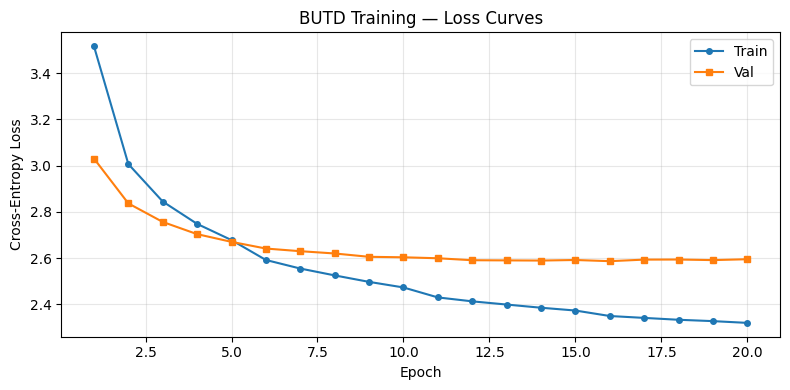

Best val loss : 2.5868


In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
epochs = range(1, len(train_losses) + 1)
ax.plot(epochs, train_losses, label="Train", marker="o", markersize=4)
ax.plot(epochs, val_losses,   label="Val",   marker="s", markersize=4)
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss")
ax.set_title("BUTD Training — Loss Curves")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("notebooks/butd_loss_curve.png", dpi=120)
plt.show()
print(f"Best val loss : {best_val_loss:.4f}")

## 9. Evaluation (BLEU / METEOR)

In [ ]:
from src.training.train_butd import generate_captions
from src.eval.metrics import evaluate_captions

# Load best checkpoint
checkpoint = torch.load(CHECKPOINT_DIR / "best.pt", map_location=device, weights_only=True)
model.load_state_dict(checkpoint["model_state_dict"])
print(f"Loaded epoch {checkpoint['epoch']}  (val_loss={checkpoint['val_loss']:.4f})")

# Generate one caption per unique val image
print("Generating captions …")
val_predictions = generate_captions(model, val_loader, vocab, device)
print(f"Generated {len(val_predictions)} captions")

# Build reference dict
val_references = {iid: caption_map[iid] for iid in val_predictions if iid in caption_map}

scores = evaluate_captions(val_references, val_predictions, require_exact_match=False)
print("\n=== Validation Scores ===")
for metric, score in scores.items():
    print(f"  {metric.upper():8s}: {score:.4f}")

Loaded epoch 16  (val_loss=2.5868)
Generating captions …
Generated 3178 captions

=== Validation Scores ===
  BLEU_1  : 0.6318
  BLEU_2  : 0.4175
  BLEU_3  : 0.2768
  BLEU_4  : 0.1854
  METEOR  : 0.3920


## 10. Sample Predictions

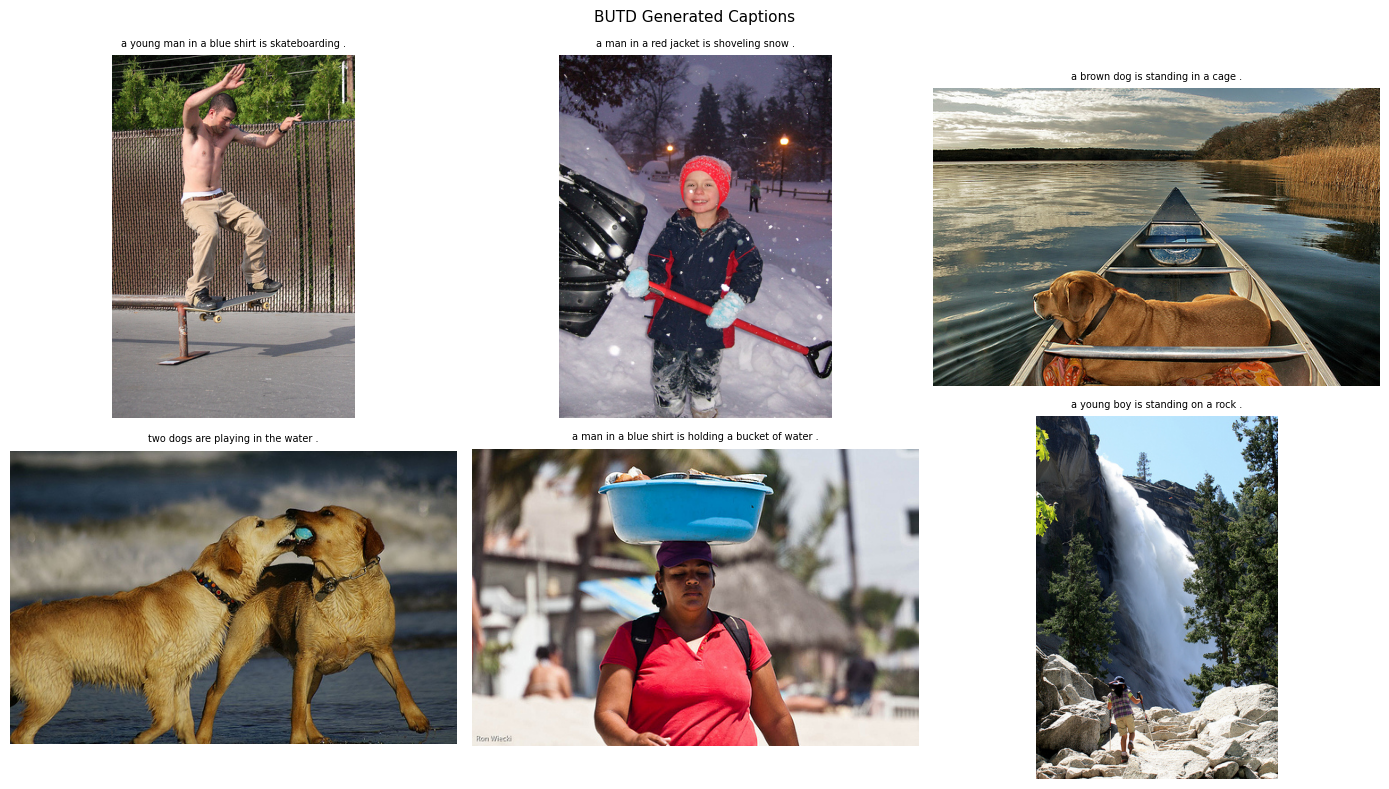

In [ ]:
import random
from PIL import Image

sample_ids = random.sample(sorted(val_predictions.keys()), min(6, len(val_predictions)))

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, iid in zip(axes.flatten(), sample_ids):
    img_path = IMAGES_DIR / iid
    if img_path.exists():
        ax.imshow(Image.open(img_path).convert("RGB"))
    ax.axis("off")
    ax.set_title(val_predictions[iid], fontsize=7, wrap=True)
fig.suptitle("BUTD Generated Captions", fontsize=11)
fig.tight_layout()
plt.show()

In [ ]:
for iid in sample_ids:
    print(f"Image : {iid}")
    print(f"  Generated : {val_predictions[iid]}")
    print("  References:")
    for ref in caption_map.get(iid, []):
        print(f"    - {ref}")
    print()

Image : 2712352554.jpg
  Generated : a young man in a blue shirt is skateboarding .
  References:
    - A boy does a skateboard trick off a metal plank .
    - A young man jumps in the air on a skateboard .
    - a guy with no shirt on is skateboarding .
    - Skater does a trick on a rail .
    - Skateboarder on a rail .

Image : 4199552427.jpg
  Generated : a man in a red jacket is shoveling snow .
  References:
    - A child wearing a red winter hat is standing in the snow holding a snow shovel with a red handle .
    - A little boy in a red hat is having fun playing in the snow .
    - A little kid with a red hat is holding a shovel in the snow .
    - A little boy in a blue jacket prepares to shovel snow .
    - A child shows off their snow shovel .

Image : 1965278563.jpg
  Generated : a brown dog is standing in a cage .
  References:
    - A golden haired dog is lying in a boat that is traveling on a lake .
    - A big brown dog floats in a canoe on the river at sunset .
    - A

## 11. Save Outputs Back to Drive

Everything is already written to your Google Drive folder since the working directory is inside Drive. Run this cell to confirm all key outputs are in place before closing the session.

In [ ]:
import json

# Save predictions JSON (for later comparison with the transformer model)
pred_path = Path("configs/butd_val_predictions.json")
with pred_path.open("w") as fh:
    json.dump(val_predictions, fh, indent=2)

# Confirm key outputs exist
checks = {
    "Best checkpoint"       : CHECKPOINT_DIR / "best.pt",
    "Predictions JSON"      : pred_path,
    "Loss curve image"      : Path("notebooks/butd_loss_curve.png"),
    "Feature files (count)" : FEATURES_DIR,
}
for label, path in checks.items():
    if path.is_dir():
        count = len(list(path.glob("*.pt")))
        print(f"  {label:25s}: {count} files")
    else:
        status = "OK" if path.exists() else "MISSING"
        print(f"  {label:25s}: {status}  ({path})")

  Best checkpoint          : OK  (checkpoints/butd/best.pt)
  Predictions JSON         : OK  (configs/butd_val_predictions.json)
  Loss curve image         : OK  (notebooks/butd_loss_curve.png)
  Feature files (count)    : 31783 files
